## 1. Imports

In [1]:
import os
import glob
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xaai_notebook_utils import get_artifacts_root, get_output_dir

print("Ready for real result comparison.")


Ready for real result comparison.


## 2. Output Folder Paths

In [2]:
ARTIFACTS_ROOT = get_artifacts_root()
BONUS_OUTPUT_DIR = ARTIFACTS_ROOT / "bonus_comparison_outputs"
BONUS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FOLDERS = {
    "MobileNetV2": get_output_dir("mobilenetv2"),
    "Xception": get_output_dir("xception"),
    "NASNetMobile": get_output_dir("nasnetmobile")
}

for model_name, folder in OUTPUT_FOLDERS.items():
    print(model_name, "->", folder, "| exists:", folder.exists())


MobileNetV2 -> C:\Users\ahmed\Desktop\xaai\artifacts\mobilenetv2_final_outputs | exists: True
Xception -> C:\Users\ahmed\Desktop\xaai\artifacts\xception_final_outputs | exists: True
NASNetMobile -> C:\Users\ahmed\Desktop\xaai\artifacts\nasnetmobile_final_outputs | exists: True


## 3. Load Real Saved Outputs

In [3]:
def load_model_outputs(model_name, folder):
    prefix_map = {
        "MobileNetV2": "mobilenetv2",
        "Xception": "xception",
        "NASNetMobile": "nasnetmobile"
    }

    prefix = prefix_map[model_name]

    true_path = folder / f"{prefix}_y_true.npy"
    pred_path = folder / f"{prefix}_y_pred.npy"
    prob_path = folder / f"{prefix}_y_prob.npy"
    class_path = folder / "class_names.json"

    if not true_path.exists() or not pred_path.exists() or not prob_path.exists():
        raise FileNotFoundError(f"Missing output files for {model_name}. Run its notebook first.")

    y_true = np.load(true_path)
    y_pred = np.load(pred_path)
    y_prob = np.load(prob_path)

    if class_path.exists():
        with open(class_path, "r") as f:
            class_names = json.load(f)
    else:
        class_names = [str(i) for i in range(y_prob.shape[1])]

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "class_names": class_names,
        "folder": folder
    }

results = {}

for model_name, folder in OUTPUT_FOLDERS.items():
    try:
        results[model_name] = load_model_outputs(model_name, folder)
        print(f"Loaded {model_name}:")
        print(" y_true:", results[model_name]["y_true"].shape)
        print(" y_pred:", results[model_name]["y_pred"].shape)
        print(" y_prob:", results[model_name]["y_prob"].shape)
    except Exception as e:
        print(e)

print("Loaded models:", list(results.keys()))


Loaded MobileNetV2:
 y_true: (1012,)
 y_pred: (1012,)
 y_prob: (1012, 9)
Loaded Xception:
 y_true: (1012,)
 y_pred: (1012,)
 y_prob: (1012, 9)
Loaded NASNetMobile:
 y_true: (1012,)
 y_pred: (1012,)
 y_prob: (1012, 9)
Loaded models: ['MobileNetV2', 'Xception', 'NASNetMobile']


## 4. Real Metrics Comparison

,Model,Accuracy,Precision,Recall,F1-score
0,MobileNetV2,0.943676,0.945079,0.943676,0.943668
2,NASNetMobile,0.893281,0.892374,0.893281,0.892468
1,Xception,0.874506,0.875067,0.874506,0.872608


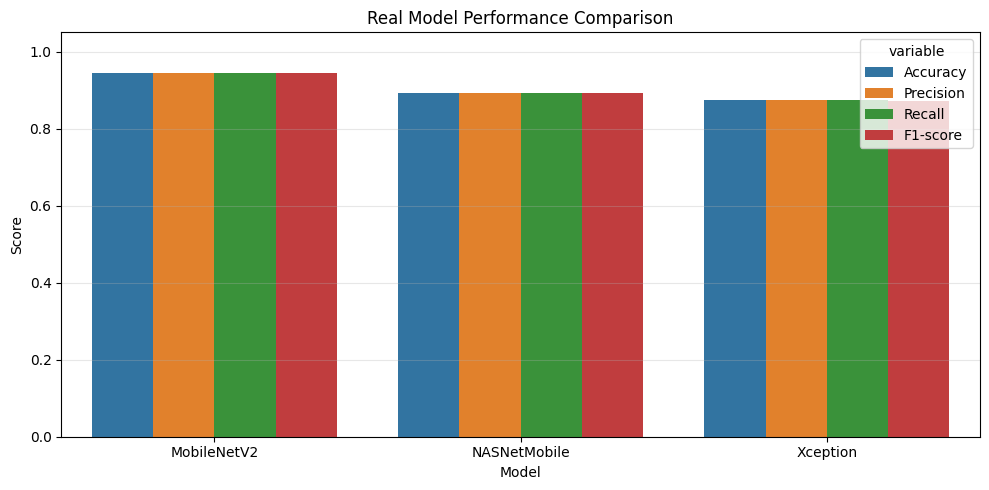

In [4]:
metric_rows = []

for model_name, data in results.items():
    y_true = data["y_true"]
    y_pred = data["y_pred"]

    metric_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    })

comparison_df = pd.DataFrame(metric_rows).sort_values("F1-score", ascending=False)
comparison_df.to_csv(BONUS_OUTPUT_DIR / "individual_model_comparison.csv", index=False)
display(comparison_df)

plt.figure(figsize=(10, 5))
comparison_melted = comparison_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1-score"])
sns.barplot(data=comparison_melted, x="Model", y="value", hue="variable")
plt.title("Real Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Best Model Based on Actual Results

In [5]:
if len(comparison_df) > 0:
    best = comparison_df.iloc[0]
    print("Best individual model based on real weighted F1-score:")
    print("Model:", best["Model"])
    print("Accuracy:", round(best["Accuracy"], 4))
    print("Precision:", round(best["Precision"], 4))
    print("Recall:", round(best["Recall"], 4))
    print("F1-score:", round(best["F1-score"], 4))
else:
    print("No model outputs loaded.")


Best individual model based on real weighted F1-score:
Model: MobileNetV2
Accuracy: 0.9437
Precision: 0.9451
Recall: 0.9437
F1-score: 0.9437


## 6. Confusion Matrices

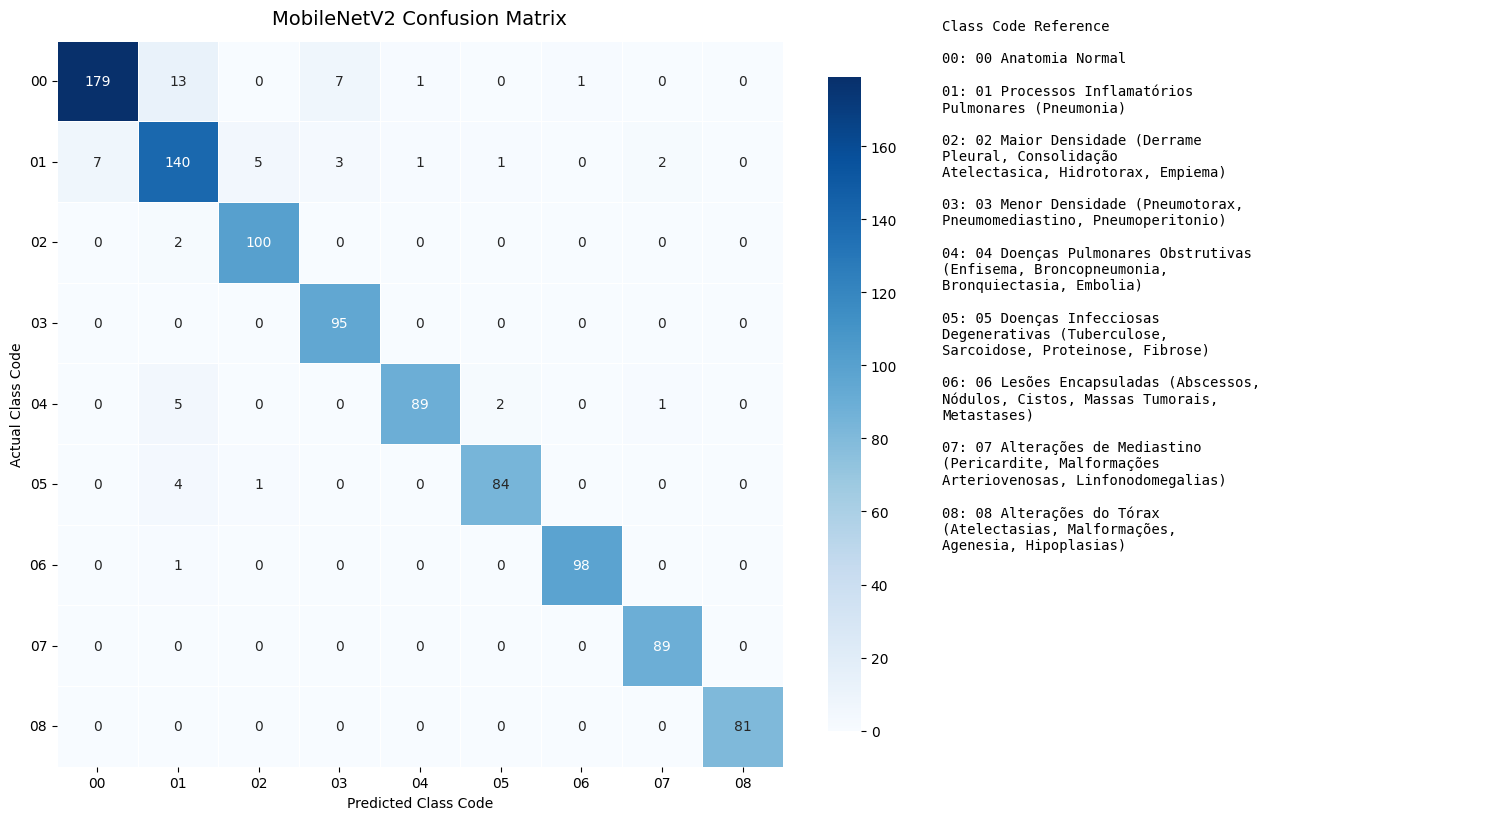

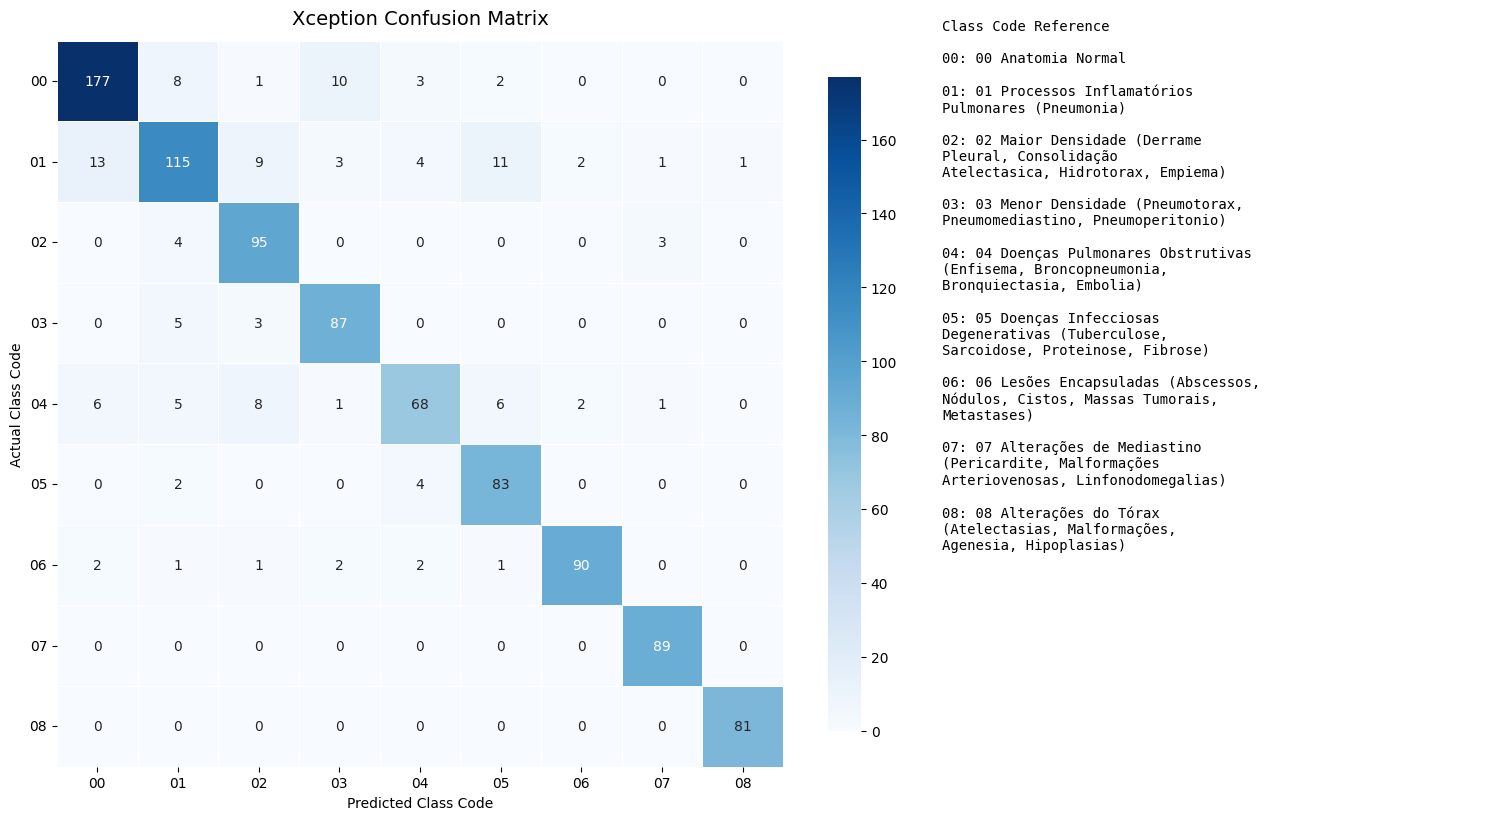

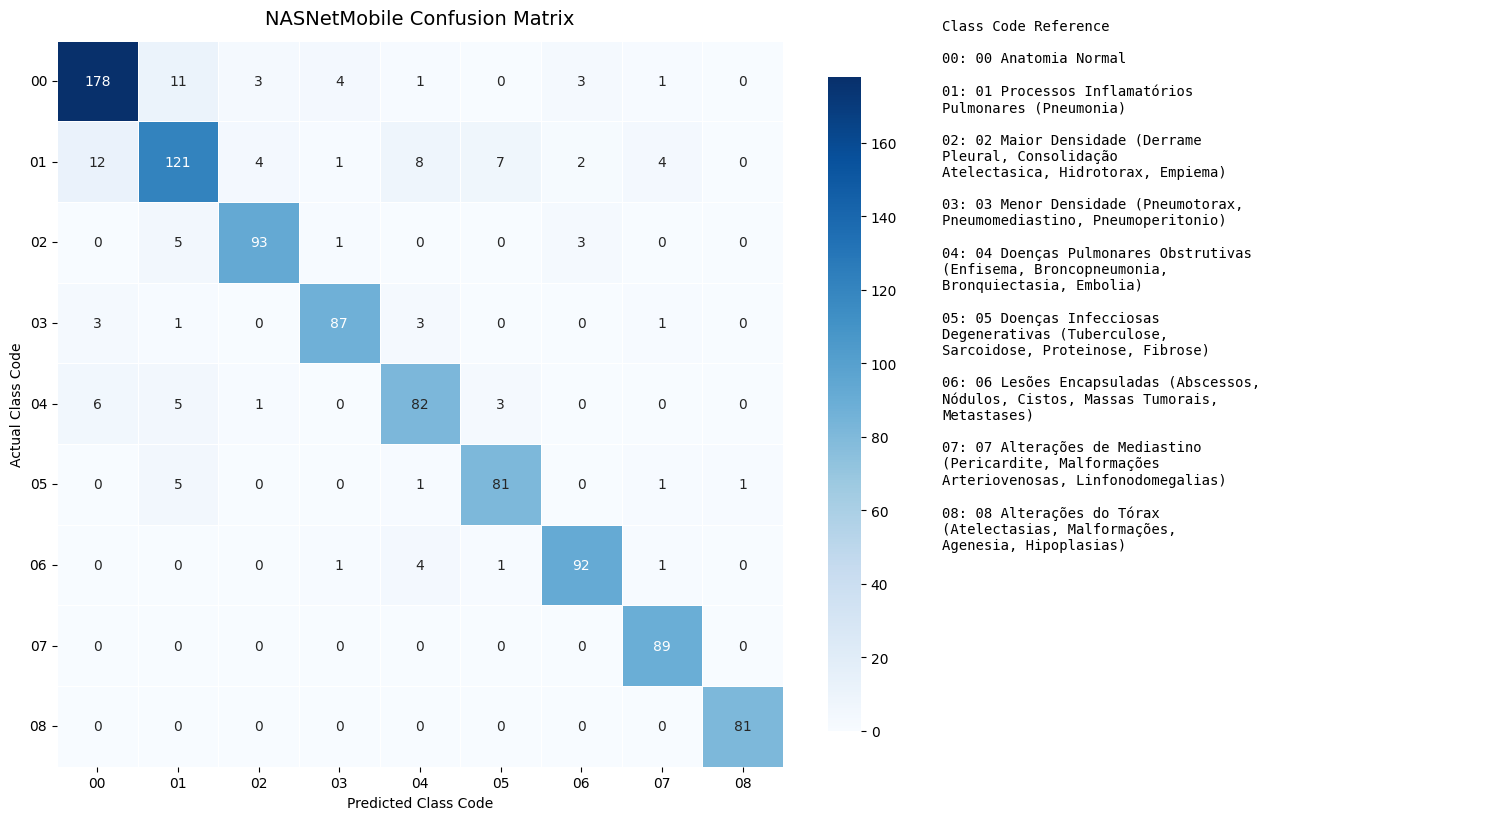

In [6]:
from textwrap import fill

for model_name, data in results.items():
    y_true = data["y_true"]
    y_pred = data["y_pred"]
    class_names = data["class_names"]

    short_class_labels = []
    for idx, class_name in enumerate(class_names):
        first_token = str(class_name).split()[0]
        short_class_labels.append(first_token if first_token.isdigit() else f"C{idx:02d}")

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=short_class_labels, columns=short_class_labels)

    fig, (ax_cm, ax_legend) = plt.subplots(
        1,
        2,
        figsize=(15, 8),
        gridspec_kw={"width_ratios": [2.7, 1.6]},
    )

    sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        square=True,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"shrink": 0.85},
        annot_kws={"size": 10},
        ax=ax_cm,
    )
    ax_cm.set_title(f"{model_name} Confusion Matrix", fontsize=14, pad=12)
    ax_cm.set_xlabel("Predicted Class Code")
    ax_cm.set_ylabel("Actual Class Code")
    ax_cm.tick_params(axis="x", rotation=0)
    ax_cm.tick_params(axis="y", rotation=0)

    ax_legend.axis("off")
    legend_lines = [
        f"{code}: {fill(str(name), width=34)}"
        for code, name in zip(short_class_labels, class_names)
    ]
    ax_legend.text(
        0,
        1,
        "Class Code Reference\n\n" + "\n\n".join(legend_lines),
        va="top",
        fontsize=10,
        family="monospace",
    )

    fig.tight_layout()
    fig.savefig(
        BONUS_OUTPUT_DIR / f"{model_name.lower().replace(' ', '_').replace('-', '_')}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 7. Classification Reports

In [7]:
for model_name, data in results.items():
    print("=" * 90)
    print(model_name)
    print("=" * 90)
    print(classification_report(
        data["y_true"],
        data["y_pred"],
        target_names=data["class_names"],
        zero_division=0
    ))


MobileNetV2
                                                                                           precision    recall  f1-score   support

                                                                       00 Anatomia Normal       0.96      0.89      0.93       201
                                        01 Processos Inflamatórios Pulmonares (Pneumonia)       0.85      0.88      0.86       159
     02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)       0.94      0.98      0.96       102
                      03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)       0.90      1.00      0.95        95
   04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)       0.98      0.92      0.95        97
      05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)       0.97      0.94      0.95        89
         06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tu

## 8. Soft-Voting Ensemble

,Model,Accuracy,Precision,Recall,F1-score
0,Soft-Voting Ensemble,0.94664,0.946896,0.94664,0.946423


,Model,Accuracy,Precision,Recall,F1-score
3,Soft-Voting Ensemble,0.946640,0.946896,0.946640,0.946423
0,MobileNetV2,0.943676,0.945079,0.943676,0.943668
1,NASNetMobile,0.893281,0.892374,0.893281,0.892468
2,Xception,0.874506,0.875067,0.874506,0.872608


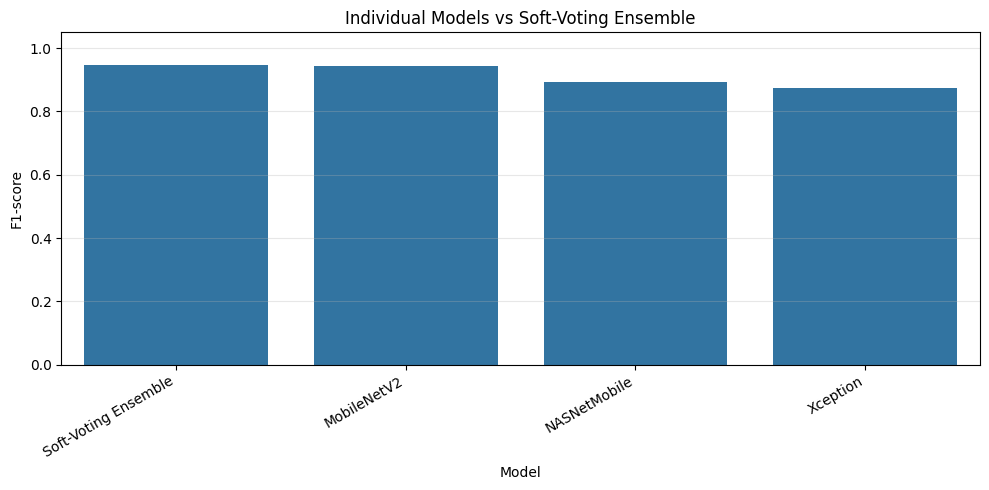

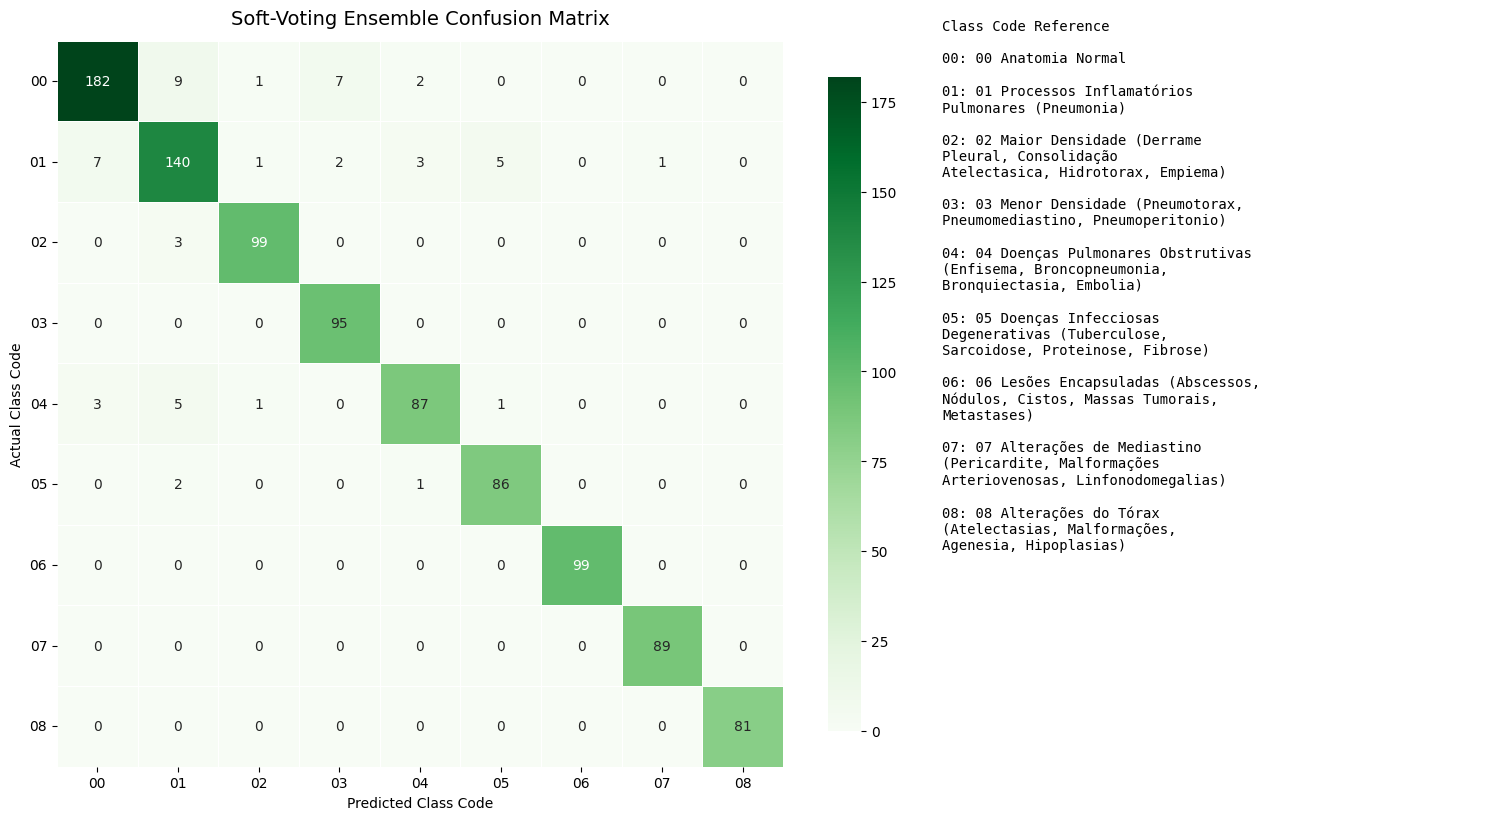

In [8]:
compatible_models = {}
reference_shape = None
reference_true = None
reference_classes = None

for model_name, data in results.items():
    prob_shape = data["y_prob"].shape

    if reference_shape is None:
        reference_shape = prob_shape
        reference_true = data["y_true"]
        reference_classes = data["class_names"]

    if prob_shape == reference_shape and np.array_equal(data["y_true"], reference_true):
        compatible_models[model_name] = data
    else:
        print(f"Skipping {model_name}: different test set or probability shape.")

if len(compatible_models) >= 2:
    ensemble_prob = np.mean([d["y_prob"] for d in compatible_models.values()], axis=0)
    ensemble_pred = np.argmax(ensemble_prob, axis=1)
    y_true = reference_true

    ensemble_metrics = pd.DataFrame([{
        "Model": "Soft-Voting Ensemble",
        "Accuracy": accuracy_score(y_true, ensemble_pred),
        "Precision": precision_score(y_true, ensemble_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, ensemble_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_true, ensemble_pred, average="weighted", zero_division=0)
    }])

    display(ensemble_metrics)

    final_comparison_df = pd.concat([comparison_df, ensemble_metrics], ignore_index=True)
    final_comparison_df = final_comparison_df.sort_values("F1-score", ascending=False)
    final_comparison_df.to_csv(BONUS_OUTPUT_DIR / "final_comparison_with_ensemble.csv", index=False)
    display(final_comparison_df)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=final_comparison_df, x="Model", y="F1-score")
    plt.title("Individual Models vs Soft-Voting Ensemble")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    short_class_labels = []
    for idx, class_name in enumerate(reference_classes):
        first_token = str(class_name).split()[0]
        short_class_labels.append(first_token if first_token.isdigit() else f"C{idx:02d}")

    cm = confusion_matrix(y_true, ensemble_pred)
    cm_df = pd.DataFrame(cm, index=short_class_labels, columns=short_class_labels)

    fig, (ax_cm, ax_legend) = plt.subplots(
        1,
        2,
        figsize=(15, 8),
        gridspec_kw={"width_ratios": [2.7, 1.6]},
    )

    sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Greens",
        square=True,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"shrink": 0.85},
        annot_kws={"size": 10},
        ax=ax_cm,
    )
    ax_cm.set_title("Soft-Voting Ensemble Confusion Matrix", fontsize=14, pad=12)
    ax_cm.set_xlabel("Predicted Class Code")
    ax_cm.set_ylabel("Actual Class Code")
    ax_cm.tick_params(axis="x", rotation=0)
    ax_cm.tick_params(axis="y", rotation=0)

    ax_legend.axis("off")
    legend_lines = [
        f"{code}: {fill(str(name), width=34)}"
        for code, name in zip(short_class_labels, reference_classes)
    ]
    ax_legend.text(
        0,
        1,
        "Class Code Reference\n\n" + "\n\n".join(legend_lines),
        va="top",
        fontsize=10,
        family="monospace",
    )

    fig.tight_layout()
    fig.savefig(
        BONUS_OUTPUT_DIR / "soft_voting_ensemble_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

else:
    print("Not enough compatible model outputs for ensemble.")
    print("Make sure all three model notebooks use the same train/validation/test split and class order.")


## 9. XAI Metrics Comparison Based on Actual Saved Results

Loaded: C:\Users\ahmed\Desktop\xaai\artifacts\mobilenetv2_final_outputs\mobilenetv2_xai_metrics.csv
Loaded: C:\Users\ahmed\Desktop\xaai\artifacts\xception_final_outputs\xception_xai_metrics.csv
Loaded: C:\Users\ahmed\Desktop\xaai\artifacts\nasnetmobile_final_outputs\nasnetmobile_xai_metrics.csv


,XAI Method,Central Focus Score,Heatmap Entropy,Model
0,Grad-CAM,0.358326,10.805535,MobileNetV2
1,SHAP,0.467065,10.456290,MobileNetV2
2,Integrated Gradients,0.425417,10.431494,MobileNetV2
3,Occlusion Sensitivity,0.743576,9.067503,MobileNetV2
4,Grad-CAM,0.375299,10.782791,Xception
5,SHAP,0.425443,10.516185,Xception
6,Integrated Gradients,0.451747,10.371799,Xception
7,Occlusion Sensitivity,0.168430,9.502362,Xception
8,Grad-CAM,0.383361,10.804495,NASNetMobile
9,SHAP,0.401143,10.441830,NASNetMobile


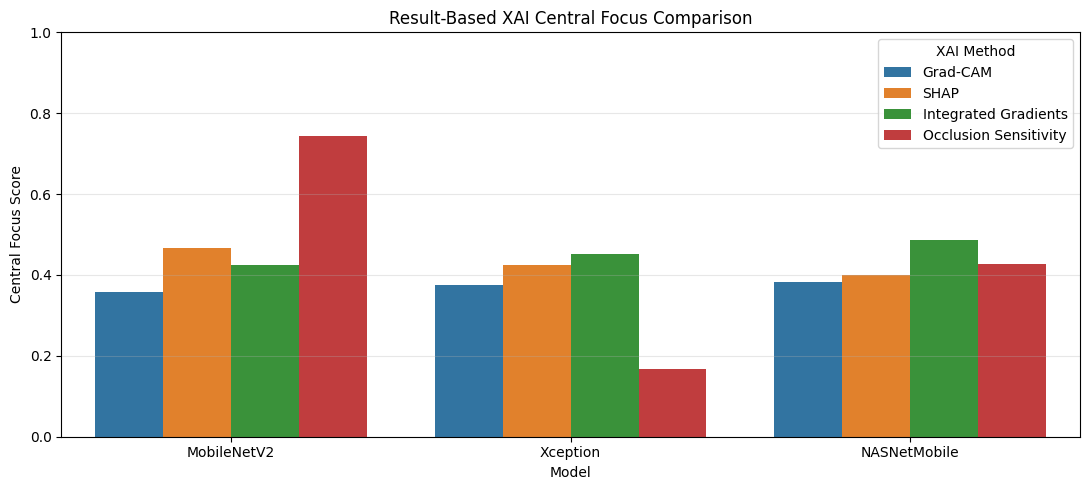

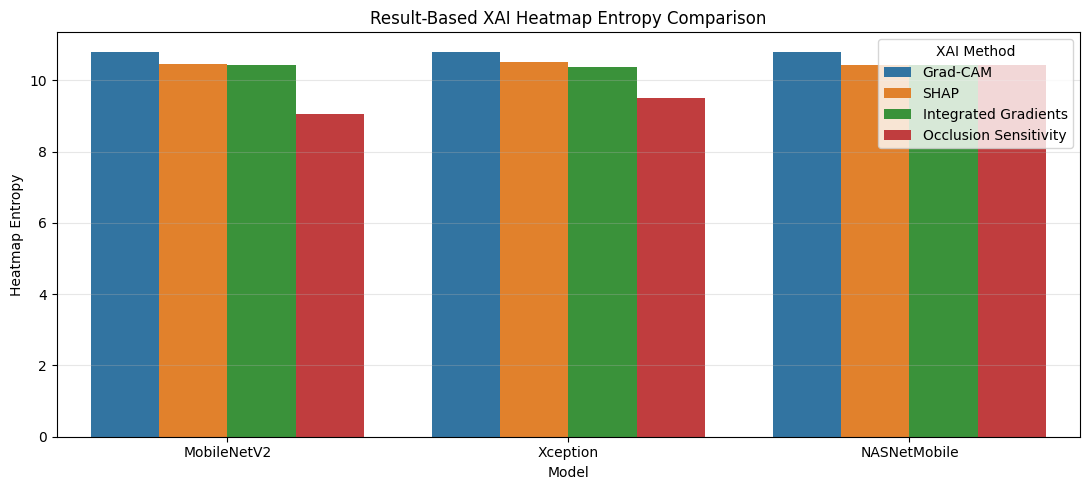

In [9]:
xai_tables = []

prefix_map = {
    "MobileNetV2": "mobilenetv2",
    "Xception": "xception",
    "NASNetMobile": "nasnetmobile"
}

for model_name, folder in OUTPUT_FOLDERS.items():
    prefix = prefix_map[model_name]
    xai_path = folder / f"{prefix}_xai_metrics.csv"

    if xai_path.exists():
        xai_df = pd.read_csv(xai_path)
        xai_df["Model"] = model_name
        xai_tables.append(xai_df)
        print("Loaded:", xai_path)
    else:
        print("Missing XAI metrics for:", model_name)

if xai_tables:
    all_xai_df = pd.concat(xai_tables, ignore_index=True)
    all_xai_df.to_csv(BONUS_OUTPUT_DIR / "xai_metrics_comparison.csv", index=False)
    display(all_xai_df)

    plt.figure(figsize=(11, 5))
    sns.barplot(data=all_xai_df, x="Model", y="Central Focus Score", hue="XAI Method")
    plt.title("Result-Based XAI Central Focus Comparison")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(11, 5))
    sns.barplot(data=all_xai_df, x="Model", y="Heatmap Entropy", hue="XAI Method")
    plt.title("Result-Based XAI Heatmap Entropy Comparison")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No XAI metrics found. Run the XAI cells in the three model notebooks first.")


## 10. Automatic Result-Based Discussion

In [10]:
if len(comparison_df) > 0:
    print("FINAL RESULT-BASED DISCUSSION")
    print("=" * 90)

    best = comparison_df.iloc[0]
    weakest = comparison_df.iloc[-1]

    print(f"The best individual model is {best['Model']} based on weighted F1-score.")
    print(f"It achieved Accuracy = {best['Accuracy']:.4f}, Precision = {best['Precision']:.4f}, Recall = {best['Recall']:.4f}, and F1-score = {best['F1-score']:.4f}.")
    print()
    print(f"The weakest individual model in this run is {weakest['Model']} with F1-score = {weakest['F1-score']:.4f}.")
    print()

    if "final_comparison_df" in globals():
        best_overall = final_comparison_df.iloc[0]
        print(f"After adding the soft-voting ensemble, the best overall method is {best_overall['Model']} with F1-score = {best_overall['F1-score']:.4f}.")

        if best_overall["Model"] == "Soft-Voting Ensemble":
            print("The ensemble improved the final result, supporting the bonus criterion of advanced model design.")
        else:
            print("The ensemble did not outperform the best individual model in this run, but it provides a valid experimental comparison.")

    if "all_xai_df" in globals():
        print()
        print("For explainability, the XAI metrics table compares the attention concentration and entropy of the produced heatmaps.")
        print("Higher central focus suggests stronger attention inside the medically relevant central lung area.")
        print("Entropy helps describe whether explanations are concentrated or scattered.")

else:
    print("No real results loaded yet.")


FINAL RESULT-BASED DISCUSSION
The best individual model is MobileNetV2 based on weighted F1-score.
It achieved Accuracy = 0.9437, Precision = 0.9451, Recall = 0.9437, and F1-score = 0.9437.

The weakest individual model in this run is Xception with F1-score = 0.8726.

After adding the soft-voting ensemble, the best overall method is Soft-Voting Ensemble with F1-score = 0.9464.
The ensemble improved the final result, supporting the bonus criterion of advanced model design.

For explainability, the XAI metrics table compares the attention concentration and entropy of the produced heatmaps.
Higher central focus suggests stronger attention inside the medically relevant central lung area.
Entropy helps describe whether explanations are concentrated or scattered.
